# Plots

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pickle

In [2]:
# cost facots from 5 to 100 in steps of 5
cost_factors = list(range(5, 31, 5))
N = 2**16

# import building table data
df_building = pd.read_csv(f'results/building/building_table_results_updated.csv')

# compute actual cost
df_building["actual_cost"] = df_building["hashes"] + (df_building["reductions"] * (1 / 577.44)) # update reduction cost to 1/577.44 from 1/557.3



## Plot precomputation

### num endpoints


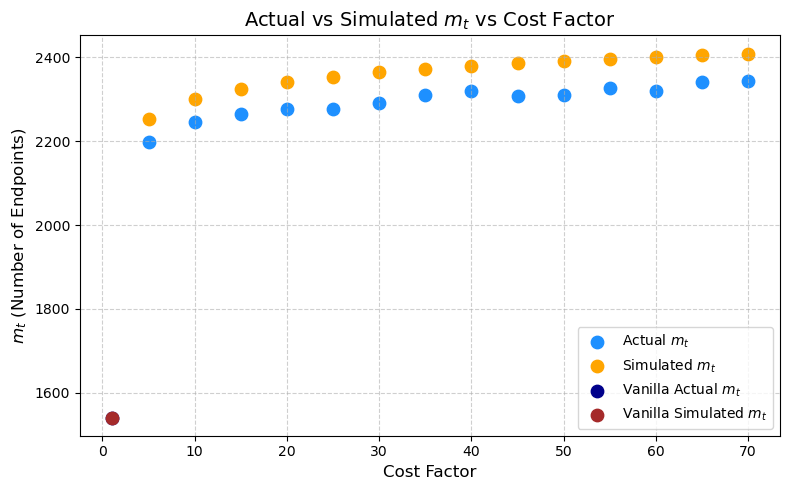

In [3]:
# Scatter plot for actual vs simulated m_t
plt.figure(figsize=(8, 5))
plt.scatter(df_building["cost_factor"], df_building["actual_mt"], color="dodgerblue", marker="o", s=80, label="Actual $m_t$")
plt.scatter(df_building["cost_factor"], df_building["simulated_mt"], color="orange", marker="o", s=80, label="Simulated $m_t$")
plt.scatter(1, 1541, color="darkblue", marker="o", s=80, label="Vanilla Actual $m_t$")
plt.scatter(1, 1541, color="brown", marker="o", s=80, label="Vanilla Simulated $m_t$")

# Add labels and title
plt.title("Actual vs Simulated $m_t$ vs Cost Factor", fontsize=14)
plt.xlabel("Cost Factor", fontsize=12)
plt.ylabel("$m_t$ (Number of Endpoints)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()


### Plot box plots

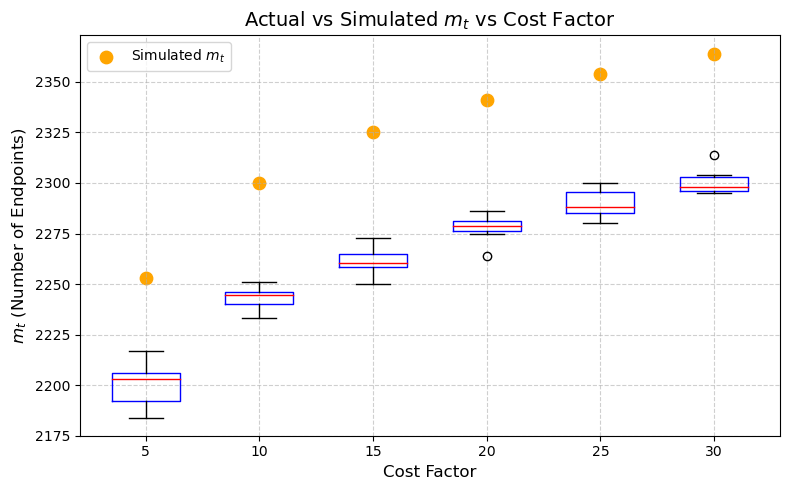

In [8]:
# we have simulateed data, now we need to get the actual data from the different runs
# thenn plot a box plot for each cost factor showing the distribution of actual mt values
# all 10 samples are in the csv file
# we can just read them in and plot them

sample_size = 10  # number of samples per cost factor

# make the figure
plt.figure(figsize=(8, 5))

data = []
for cost_factor in cost_factors:
    # open the csv file
    df_samples = pd.read_csv(f'constructed_tables/different_sp/building_table_results_cost_{cost_factor}.csv')

    mt_values = df_samples["actual_mt"].values

    # plot a box plot for this cost factor
    plt.boxplot(mt_values, positions=[cost_factor], widths=3, boxprops=dict(color="blue"), medianprops=dict(color="red"))   

    # store the data for later use
    data.append(mt_values)

# plot scatter points for simulated mt
# need to get the subset of the number of boxplots done
df_subplot = df_building.iloc[:(len(cost_factors))]
plt.scatter(df_subplot["cost_factor"], df_subplot["simulated_mt"],    color="orange", marker="o", s=80, label="Simulated $m_t$")

# plot scatter for vanilla - should make this a box plot too
# plt.scatter(1, 1541, color="darkblue", marker="o", s=80, label="Vanilla Actual $m_t$")
# plt.scatter(1, 1541, color="brown", marker="o", s=80, label="Vanilla Simulated $m_t$")


# Add labels and title
plt.title("Actual vs Simulated $m_t$ vs Cost Factor", fontsize=14)
plt.xlabel("Cost Factor", fontsize=12)
plt.ylabel("$m_t$ (Number of Endpoints)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()


### cost

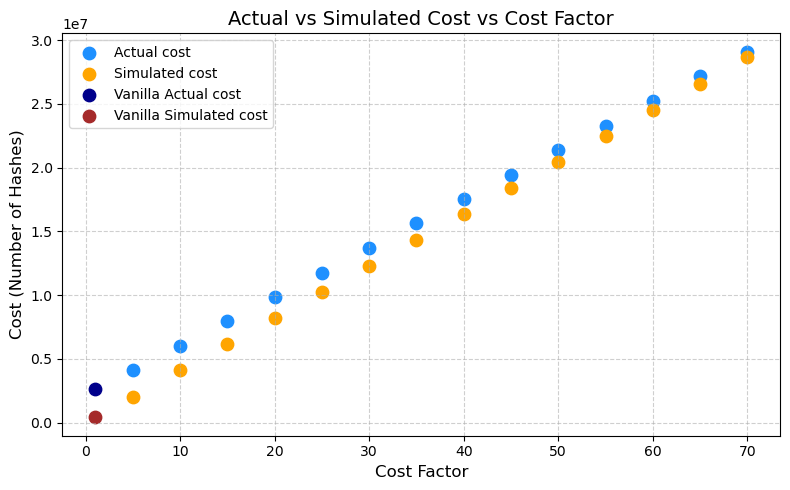

In [5]:
# Scatter plot for actual vs simulated m_t
plt.figure(figsize=(8, 5))
plt.scatter(df_building["cost_factor"], df_building["actual_cost"], color="dodgerblue", marker="o", s=80, label="Actual cost")
plt.scatter(df_building["cost_factor"], df_building["simulated_cost"], color="orange", marker="o", s=80, label="Simulated cost")
plt.scatter(1, 2600800, color="darkblue", marker="o", s=80, label="Vanilla Actual cost")
plt.scatter(1, 406053.8237331421, color="brown", marker="o", s=80, label="Vanilla Simulated cost")

# Add labels and title
plt.title("Actual vs Simulated Cost vs Cost Factor", fontsize=14)
plt.xlabel("Cost Factor", fontsize=12)
plt.ylabel("Cost (Number of Hashes)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

## Searching

In [6]:
# want to store coverage, 
coverages = []
costs = []
false_alarms_true = []
false_alarms_false = []

for c in cost_factors:
    filename = f"results/searching/searching_table_results_cost_{c}.csv"
    df = pd.read_csv(filename)

    # calculate coverage
    found_count = df["found"].sum()

    coverage = (found_count / N ) * 100

    coverages.append(coverage)

    # calculate average cost
    avg_cost = (df["hashes"].sum() + (df["reductions"] * (1 / 557.3)).sum()) / N
    costs.append(avg_cost)

    # calculate average false alarms
    false_alarm_avg = df.groupby('found')['false_alarms'].mean()
    
    # store separately for found=True and found=False
    # 
    false_alarms_true.append(false_alarm_avg.iloc[1])   # if point was found
    false_alarms_false.append(false_alarm_avg.iloc[0])  # if point was not found

# vanilla data
filename = f"results/searching/searching_vanilla_table_results.csv"
df = pd.read_csv(filename)
# calculate coverage
Vfound_count = df["found"].sum()
Vcost = (df["hashes"].sum() + (df["reductions"] * (1 / 557.3)).sum()) / N
Vcoverage = (Vfound_count / N ) * 100
# calculate average false alarms
Vfalse_alarm_avg = df.groupby('found')['false_alarms'].mean()

# add headers - line up headers with columns
print(f"{'Cost Factor':<12} | {'Coverage':<8} | {'Cost':<8} | {'False Alarms - True':<20} | {'False Alarms - False':<21}")

# add line separator
print("-" * 81)

# add vanilla results
print(f"{'Vanilla':<12} | {Vcoverage:>7.2f}% | {Vcost:>8.2f} | {Vfalse_alarm_avg.iloc[1]:>20.2f} | {Vfalse_alarm_avg.iloc[0]:>21.2f}")

# add cherry results
for c, cov, cos, faT, faF in zip(cost_factors, coverages, costs, false_alarms_true, false_alarms_false):
    print(f"{c:<12} | {cov:>7.2f}% | {cos:>8.2f} | {faT:>20.2f} | {faF:>21.2f}")


Cost Factor  | Coverage | Cost     | False Alarms - True  | False Alarms - False 
---------------------------------------------------------------------------------
Vanilla      |   85.41% |  1726.91 |                11.46 |                 52.46
5            |   93.26% |  1347.63 |                10.87 |                 57.92
10           |   93.85% |  1304.79 |                10.64 |                 57.90
15           |   93.93% |  1294.01 |                10.54 |                 57.89
20           |   94.14% |  1291.77 |                10.65 |                 58.27
25           |   94.09% |  1290.50 |                10.60 |                 58.06
30           |   94.09% |  1296.32 |                10.71 |                 58.45


## Plot Vanilla M Values

In [7]:
# import simulated m_values
vanilla_simulated = pd.read_pickle("simulations/vanilla_N_16__alpha_0.95_sim_results.pkl")
# data is in the form [kjs, m_0, final_cost, m_values] and we just need the m_values
v_sim_m_values = vanilla_simulated[3]

# get actual m_values from csv
vanilla_actual = pd.read_csv("vanilla_N_16_alpha_0.95_m_values.csv")

# plot vanilla m_values
plt.figure(figsize=(8, 5))
plt.plot(range(len(vanilla_actual)-1), vanilla_actual["m_value"][1:], label="Actual $m_i$", color="dodgerblue")
plt.plot(range(len(v_sim_m_values)), v_sim_m_values, label="Simulated $m_i$", color="orange")
plt.legend()

plt.title("Vanilla Actual vs Simulated $m_i$", fontsize=14)
plt.xlabel("i", fontsize=12)
plt.ylabel("$m_i$ (Number of Endpoints)", fontsize=12)
plt.show()

ModuleNotFoundError: No module named 'numpy._core.numeric'

In [ ]:
vanilla_simulated

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 32510,
 np.float64(404494.0249884667),
 [32510,
  25629.764381344437,
  21212.39152285474,
  18121.80138209917,
  15832.231480093644,
  14065.074940120903,
  12658.286197965135,
  11510.939764085968,
  10556.781512869413,
  9750.460965659317,
  9059.860019656786,
  8461.578174346294,
  7938.153006889501,
  7476.283043523472,
  7065.654353924867,
  6698.143954625819,
  6367.265762936775,
  6067.776947630526,
  5795.392902461113,
  5546.5773530019505,
  5318.3854258166975,
  5108.344693499246,
  4914.3638735190325,
  4734.661949377332,
  4567.712568577794,
  4412.200003832222,
  4266.983962168633,
  4131.071232492774,
  4003.5926678976903,
  3883.7843657959675,
  3770.972177968717,
  3664.5588820261037,
  3564.0134950